In [11]:
import os
import glob
import esmpy
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import matplotlib.path as mpath

In [12]:
regions = {
    "Global": {"lat_min": -90, "lat_max": 90, "lon_min": 0, "lon_max": 360},
    "Global Land": {"lat_min": -90, "lat_max": 90, "lon_min": 0, "lon_max": 360, "over_land": True},
    "Global Ocean": {"lat_min": -90, "lat_max": 90, "lon_min": 0, "lon_max": 360, "over_ocean": True},
    "Europe": {"lat_min": 35, "lat_max": 70, "lon_min": -10, "lon_max": 40, "over_land": True}, # 35N-70N, 10W-40E
    "North America": {"lat_min": 15, "lat_max": 70, "lon_min": 198, "lon_max": 309, "over_land": True}, # 15N-75N, 140W-50W
    "South America": {"lat_min": -60, "lat_max": 15, "lon_min": 280, "lon_max": 330, "over_land": True}, # 60S-15N, 80W-30W
    "Africa": {"lat_min": -35, "lat_max": 35, "lon_min": -20, "lon_max": 55, "over_land": True}, # 35S-35N, 20W-55E
    "Asia": {"lat_min": 30, "lat_max": 75, "lon_min": 55, "lon_max": 190, "over_land": True}, # 5N-55N, 55E-180E
    "Australia": {"lat_min": -45, "lat_max": -10, "lon_min": 110, "lon_max": 155, "over_land": True}, # 45S-10S, 110E-155E
    "Tropics": {"lat_min": -20, "lat_max": 20, "lon_min": 0, "lon_max": 360}, # 20S-20N, global
    "Nino 1+2": {"lat_min": -10, "lat_max": 0, "lon_min":270 , "lon_max": 280, "over_ocean": True}, # 10S-0N, 90W-80W
    "Nino 3": {"lat_min": -5, "lat_max": 5, "lon_min": 210, "lon_max": 270, "over_ocean": True}, # 5N-5S, 150W-90W
    "Nino 3.4": {"lat_min": -5, "lat_max": 5, "lon_min": 190, "lon_max": 240, "over_ocean": True}, # 5N-5S, 170W-120W
    "Nino 4": {"lat_min": -5, "lat_max": 5, "lon_min": 160, "lon_max": 210, "over_ocean": True}, # 5N-5S, 160E-150W
    "Gulf of Mexico": {"lat_min": 18, "lat_max": 30, "lon_min": 263, "lon_max": 278, "over_ocean": True}, # 18N-30N, 97W-82W
    "North Atlantic Ocean": {"lat_min": 0, "lat_max": 60, "lon_min": 280, "lon_max": 360, "over_ocean": True}, # 0N-60N, 80W-0E
    "Indian Ocean": {"lat_min": -40, "lat_max": 30, "lon_min": 20, "lon_max": 120, "over_ocean": True}, # 40S-30N, 20E-120E
    "Western Pacific Ocean": {"lat_min": -10, "lat_max": 30, "lon_min": 120, "lon_max": 160, "over_ocean": True}, # 10S-30N, 120E-160E
    "Eastern Pacific Ocean": {"lat_min": -10, "lat_max": 30, "lon_min": 240, "lon_max": 280, "over_ocean": True}, # 10S-30N, 120W-80W
    "Southern Ocean": {"lat_min": -90, "lat_max": -60, "lon_min": 0, "lon_max": 360, "over_ocean": True}, # 90S-60S, global
    "Arctic Ocean": {"lat_min": 60, "lat_max": 90, "lon_min": 0, "lon_max": 360, "over_ocean": True}, # 60N-90N, global
    "Antarctic Ocean": {"lat_min": -90, "lat_max": -50, "lon_min": 0, "lon_max": 360, "over_ocean": True}, # 50S-90S, global
}

months = {
    "JAN": 1,
    "APR": 4,
    "JUL": 7,
    "OCT": 10
}

data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

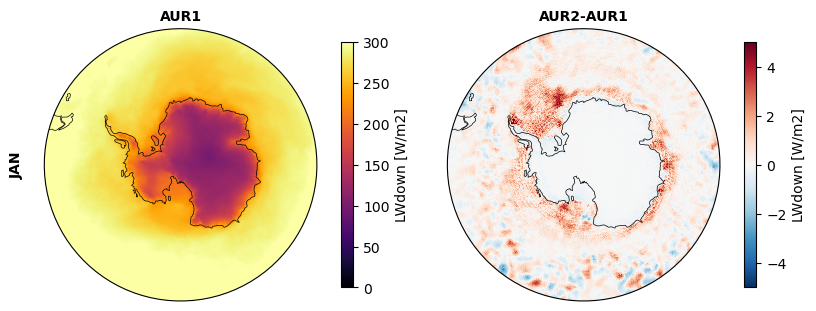

In [10]:
# Make circular boundary for polar stereographic circular plots
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# Create figure
proj  = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(1, 2, figsize=(8, 3), layout='constrained', subplot_kw={'projection': proj})

# Month
mm = 1
label = "JAN"

# Model var
model_vars = {
    "10u": ["Zonal Wind", "m/s", -20, 40, -5, 5],
    "lwdn": ["LWdown", "W/m2", 0, 300, -5, 5],
}
var = "lwdn"

# Set min and max
vmin = model_vars[var][2]
vmax = model_vars[var][3]
vmin_diff = model_vars[var][4]
vmax_diff = model_vars[var][5]

# Load datasets
ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{mm:02d}01_aurora/pred_merged_35d_remap_bil_tmean.nc"))
ds_aur2_mean = xr.open_dataset(os.path.join(data_path, f"2021{mm:02d}01_aurora_two_way/pred_merged_35d_remap_bil_tmean.nc"))

# AUR1
data_aur1 = ds_aur1_mean[var].isel(time=0)
#im0 = data_aur1.plot(ax=ax[0], transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax, cmap='inferno', add_colorbar=False)
im0 = data_aur1.plot(ax=ax[0], transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax, cmap='inferno', add_colorbar=False)
ax[0].coastlines(linewidth=0.5)
ax[0].set_boundary(circle, transform=ax[0].transAxes)
ax[0].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
fig.colorbar(im0, ax=ax[0], pad=0.08, aspect=20, shrink=0.9, label=f"{model_vars[var][0]} [{model_vars[var][1]}]")

# AUR2
data_aur2 = ds_aur2_mean[var].isel(time=0)
data_aur2 = data_aur2-data_aur1
#im1 = data_aur2.plot(ax=ax[1], transform=ccrs.PlateCarree(), vmin=vmin_diff, vmax=vmax_diff, cmap='RdBu_r', add_colorbar=False)
im1 = data_aur2.plot(ax=ax[1], transform=ccrs.PlateCarree(), vmin=vmin_diff, vmax=vmax_diff, cmap='RdBu_r', add_colorbar=False)
ax[1].coastlines(linewidth=0.5)
ax[1].set_boundary(circle, transform=ax[1].transAxes)
ax[1].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
fig.colorbar(im1, ax=ax[1], pad=0.08, aspect=20, shrink=0.9, label=f"{model_vars[var][0]} [{model_vars[var][1]}]")

# Labels
ax[0].set_title("AUR1", fontweight='bold', fontsize=10)
ax[1].set_title("AUR2-AUR1", fontweight='bold', fontsize=10)
ax[0].text(-0.1, 0.5, f"{label}", transform=ax[0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

# Save to file
filename = f"pred_{var}_aur1_vs_aur2.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

In [16]:
# from https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L40
def _latitude_cell_bounds(x: np.ndarray) -> np.ndarray:
  pi_over_2 = np.array([np.pi / 2], dtype=x.dtype)
  return np.concatenate([-pi_over_2, (x[:-1] + x[1:]) / 2, pi_over_2])
    
# From https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L45
def _cell_area_from_latitude(points: np.ndarray) -> np.ndarray:
  """Calculate the area overlap as a function of latitude."""
  bounds = _latitude_cell_bounds(points)
  upper = bounds[1:]
  lower = bounds[:-1]
  # normalized cell area: integral from lower to upper of cos(latitude)
  return np.sin(upper) - np.sin(lower)

# From https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L55
def get_lat_weights(ds: xr.Dataset) -> xr.DataArray:
  """Computes latitude/area weights from latitude coordinate of dataset."""
  weights = _cell_area_from_latitude(np.deg2rad(ds.latitude.data))
  weights /= np.mean(weights)
  weights = ds.latitude.copy(data=weights)
  return weights

In [20]:
ds_static = xr.open_dataset('/glade/derecho/scratch/turuncu/data/static.nc')
lsm = ds_static.lsm.isel(valid_time=0)
dmask = (lsm == 0)

JAN 1


KeyError: "No variable named 't2m'. Variables on the dataset include ['valid_time', 'longitude', 'latitude', 'valid_time_bnds', 'slhf', ..., 'ssrd', 'str', 'strd', 'weights', 'weights2']"

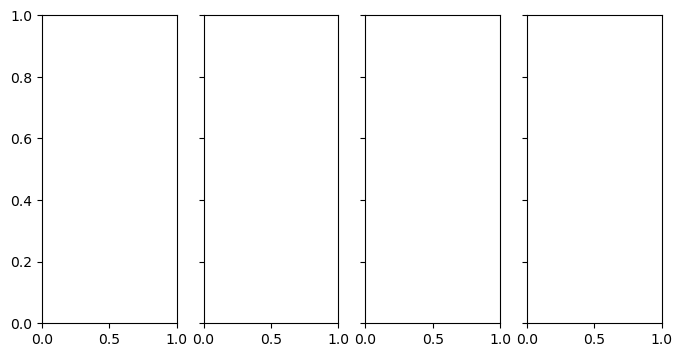

In [21]:
# Set region
reg = "Southern Ocean"
#reg = "Global"
#reg = "Arctic Ocean"
#reg = "North Atlantic Ocean"
#reg = "Nino 3.4"
#reg = "Nino 4"
#reg = "Nino 3"
#reg = "Western Pacific Ocean"
#reg = "Eastern Pacific Ocean"
#reg = "Global Ocean"

#model_var = "latent"
#model_var = "sensible"
#model_var = "LW"
#model_var = "SW"
#model_var = "LwLatSens"
#model_var = "Heat_PmE"
var_list = {
    '2t': 't2m'
}
model_var = '2t'

# Create composite time axis
t1 = pd.date_range(start='2021-01-01', end='2021-02-04', freq='1d').strftime('%Y-%m-%dT%H:%M:%S').to_list()
t2 = pd.date_range(start='2021-04-01', end='2021-05-05', freq='1d').strftime('%Y-%m-%dT%H:%M:%S').to_list()
t3 = pd.date_range(start='2021-07-01', end='2021-08-04', freq='1d').strftime('%Y-%m-%dT%H:%M:%S').to_list()
t4 = pd.date_range(start='2021-10-01', end='2021-11-04', freq='1d').strftime('%Y-%m-%dT%H:%M:%S').to_list()
time_arr = t1+t2+t3+t4

fig, ax = plt.subplots(1, 4, figsize=(8, 4), sharey=True)#, layout='constrained')

indx = 0
for label, val in months.items():
    print(label, val)
    # Load datasets
    ds_era5_daily = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_era5/era5_35d_daily.nc"))
    ds_aur1_daily = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora/pred_merged_35d_remap_bil_daily.nc"))
    ds_aur2_daily = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way/pred_merged_35d_remap_bil_daily.nc"))

    ds_era5_daily = ds_era5_daily.reindex(latitude=ds_era5_daily.latitude[::-1])
    ds_aur1_daily = ds_aur1_daily.reindex(latitude=ds_aur1_daily.latitude[::-1])
    ds_aur2_daily = ds_aur2_daily.reindex(latitude=ds_aur2_daily.latitude[::-1])

    # Calculate weights
    weights = get_lat_weights(ds_era5_daily)
    weights2d = xr.DataArray(np.tile(weights.values[:,np.newaxis], (1, ds_era5_daily.longitude.size)))
    ds_era5_daily["weights"] = (("latitude", "longitude"), weights2d.data)
    weights = np.cos(np.deg2rad(ds_era5_daily.latitude))
    weights = weights / weights.mean()
    weights2d = xr.DataArray(np.tile(weights.values[:,np.newaxis], (1, ds_era5_daily.longitude.size)))
    ds_era5_daily["weights2"] = (("latitude", "longitude"), weights2d.data)

    # Get region extent
    lat_min = regions[reg]['lat_min']
    lat_max = regions[reg]['lat_max']
    lon_min = regions[reg]['lon_min']
    lon_max = regions[reg]['lon_max']

    # Subset datasets
    ds_era5_subset = ds_era5_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
    ds_aur1_subset = ds_aur1_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
    ds_aur2_subset = ds_aur2_daily.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max)) 

    # Calculate correlation and RMSE
    #data = {
    #    "ERA5": ds_era5_subset,
    #    "DATM": ds_datm_subset,
    #    "AUR1": ds_aur1_subset,
    #    "AUR2": ds_aur2_subset
    #}
    #RMSE_dict = {}
    #CORR_dict = {}
    #for label2, d in data.items():
    #    RMSE = np.sqrt(((d.sst - ds_oisst_subset.sst) ** 2).weighted(weights).mean(dim=['latitude', 'longitude']))
    #    RMSE = RMSE.mean(dim=['time']).values
    #    RMSE_dict[label2] = RMSE
    #    CORR = CORR.mean(dim=['time']).values
    #    CORR = xs.pearson_r(ds_oisst_subset.sst, d.sst, skipna=True, dim=['latitude', 'longitude'])
    #    CORR_dict[label2] = CORR

    # Create mask
    #ds_oisst = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_oisst/oisst_35d_remap_bil.nc")).isel(zlev=0)
    #ds_oisst = ds_oisst.reindex(latitude=ds_oisst.latitude[::-1])
    #ds_oisst_subset = ds_oisst.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
    #ice_mask = ds_oisst_subset.ice.notnull() #*100 # > 15
    #data_mask = ds_era5_subset.sst.notnull()
    #dmask = data_mask #(data_mask | ice_mask)
    #dmask.isel(time=0).plot()
    #sys.exit()
    # Create mask
    #dmask = ds_era5_subset.SST.notnull()
    
    # Calculate area weighted mean
    data_era5 = ds_era5_subset[var_list[model_var]].where(dmask).weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])
    data_aur1 = ds_aur1_subset[model_var].where(dmask).weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])
    data_aur2 = ds_aur2_subset[model_var].where(dmask).weighted(ds_era5_subset.weights).mean(dim=["longitude", "latitude"])

    # Plot
    time = data_datm.time.values
    ax[indx].plot(time, data_datm, color='green', label=f"ERA5")
    ax[indx].plot(time, data_aur1, color='blue', label=f"AUR1")
    ax[indx].plot(time, data_aur2, color='cyan', label=f"AUR2")

    # Rotate x tick labels
    ax[indx].set_xticks(time[::15])
    ax[indx].tick_params(axis='x', labelrotation=45)
    ax[indx].set_xlabel('Time')

    # Handle axises
    if indx == 0:
        ax[indx].spines['left'].set_visible(True)
        ax[indx].set_ylabel(r'Sea Surface Temperature ($^\circ$C)')
    else:
        ax[indx].set_ylabel('')
    if indx == 3:
        ax[indx].spines['right'].set_visible(True)

    # Add title
    ax[indx].set_title(f"{label}", fontweight='bold', fontsize=10)

    # Add legend
    if indx in [0]:
        ax[indx].legend(ncol=1, fontsize=7, loc='lower left')
    else:
        ax[indx].legend(ncol=1, fontsize=7, loc='upper left')

    # Add text
    if indx == 3:
        ax[indx].text(1.1, 0.5, f"{reg}", transform=ax[indx].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    indx = indx+1

filename = f"timeseries_sst_{reg}.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)